In [1]:
# import standard tools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# stop pandas from hiding columns
pd.set_option('display.width', 120)

# load the files member 2 saved in the data folder
train_df = pd.read_csv('../data/train_outliers.csv')
test_df = pd.read_csv('../data/test_outliers.csv')

print("train set shape:", train_df.shape)
print("test set shape:", test_df.shape)

train set shape: (5455, 96)
test set shape: (1364, 96)


In [2]:
# separate the target col so we dont accidentally scale 0 and 1
y_train = train_df['Bankrupt?']
X_train = train_df.drop(columns=['Bankrupt?'])

y_test = test_df['Bankrupt?']
X_test = test_df.drop(columns=['Bankrupt?'])

# setup the scaler (makes mean=0 and variance=1)
scaler = StandardScaler()

# fit ONLY on train data to prevent data leakage
scaler.fit(X_train)

# transform both train and test using train's rules
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# sklearn returns numpy arrays, so turn them back into pandas dfs
# and put the original column names back
train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# reattach the target columns
train_scaled_df['Bankrupt?'] = y_train.values
test_scaled_df['Bankrupt?'] = y_test.values

print("scaling done.")

scaling done.


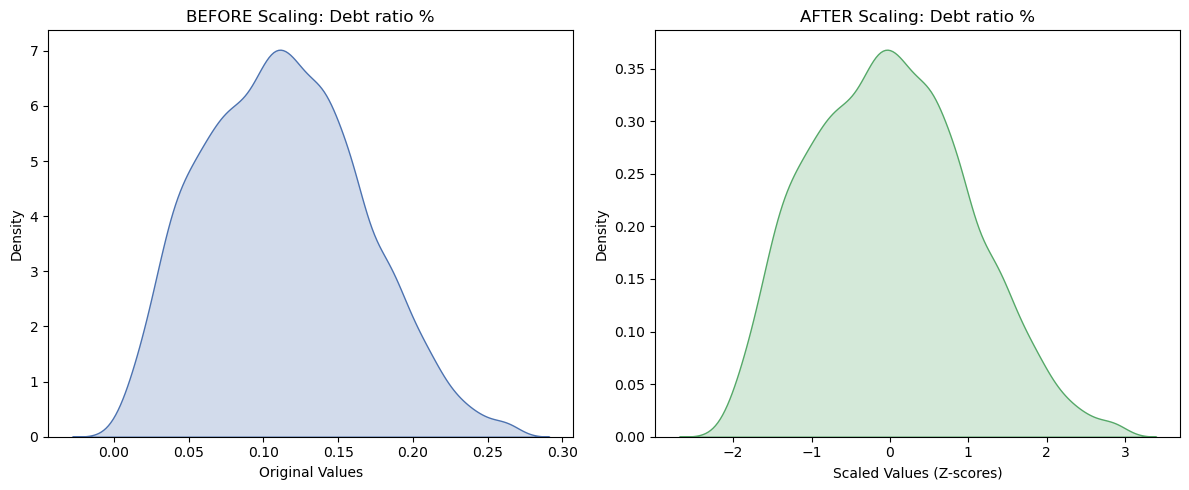

In [3]:
# pick one feature to show the before and after effect
feature_to_plot = 'Debt ratio %'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# before scaling visual (using member 2's data)
sns.kdeplot(train_df[feature_to_plot], ax=axes[0], color='#4C72B0', fill=True)
axes[0].set_title(f'BEFORE Scaling: {feature_to_plot}')
axes[0].set_xlabel('Original Values')

# after scaling visual (using member 3's data)
sns.kdeplot(train_scaled_df[feature_to_plot], ax=axes[1], color='#55A868', fill=True)
axes[1].set_title(f'AFTER Scaling: {feature_to_plot}')
axes[1].set_xlabel('Scaled Values (Z-scores)')

plt.tight_layout()

# save to eda results folder
plt.savefig('../results/eda_visualizations/member3_scaling_comparison.png', dpi=110)
plt.show()

In [4]:
# save intermediate files to data folder for member 4
train_scaled_df.to_csv('../data/train_scaled.csv', index=False)
test_scaled_df.to_csv('../data/test_scaled.csv', index=False)

print("saved train_scaled.csv and test_scaled.csv")

saved train_scaled.csv and test_scaled.csv
